# Evaluación 2 — ¿Ayuda inicializar una red neuronal en la base de Fourier?

**Programación Científica 2026-1 · Universidad Nacional de Colombia, sede Medellín**

**Juan Felipe Ramírez Gaviria** · Enunciado personalizado **ID 3714**

**Parámetros del enunciado:** $K=30$ frecuencias · 2000 iteraciones · $\eta = 0.02$ · 12 señales por régimen · régimen foco = **1** · umbral de compresión = **90 %** de la energía.

---

Autoencoder de dos capas $\hat x = W_2\,\tanh(W_1 x)$ entrenado sobre las señales de `datos_3714.npz`. Se comparan dos puntos de partida para $W_1$ — la **matriz de Fourier** (senos y cosenos) y una matriz **aleatoria** — en reconstrucción, velocidad de convergencia y compresión.

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)   # reproducibilidad numérica

# Estilo global de las figuras (visualización científica: consistencia y legibilidad)
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "legend.frameon": False,
})
C_FOURIER, C_RANDOM = "#1f77b4", "#d62728"          # azul = Fourier, rojo = aleatoria
C_REG = ["#2c7bb6", "#fdae61", "#d7191c"]           # regímenes 0,1,2 (frío -> caliente = frecuencias bajas -> altas)
print("JAX", jax.__version__)

JAX 0.7.2


## 1 · Los datos

`datos_3714.npz` contiene `X` (señales medidas por el sensor), `y` (régimen de dispersión: 0 = sin dispersión, 1 = intermedia, 2 = fuerte) y `t` (256 instantes de muestreo en $[0,1)$ s).

In [42]:
datos = np.load("datos_3714.npz", allow_pickle=True)
X, y, t = datos["X"], datos["y"], datos["t"]
N = X.shape[1]                 # 256 muestras por señal
K = 30                         # frecuencias de la capa (enunciado ID 3714)

print(f"X: {X.shape}  |  y: {y.shape}  |  t: {t.shape}")
print("señales por régimen:", np.bincount(y))

energia_media = (X**2).mean()
print(f"\nEnergía media del dataset  (X**2).mean() = {energia_media:.3f}")

X: (36, 256)  |  y: (36,)  |  t: (256,)
señales por régimen: [12 12 12]

Energía media del dataset  (X**2).mean() = 0.715


**Energía media del dataset: `0.715`.** ¿Para qué reportarla? Cumple tres funciones: (i) es una *huella* del dataset — como los datos son únicos por ID, este número certifica que todo el análisis se hizo sobre los datos propios; (ii) fija la **escala de referencia** contra la cual tiene sentido un error de reconstrucción (un error cuadrático de 0.01 es pequeño *porque* la energía típica es ~0.7); y (iii) es la cantidad que se reparte entre coeficientes en la parte de compresión (Parseval): hablar de "90 % de la energía" requiere saber cuánta energía hay.

La figura siguiente muestra una señal de cada régimen con su espectro. Se usa **línea** para las series de tiempo (datos ordenados y densos) y **tallos** para el espectro (los modos son discretos). Los colores van de frío a caliente siguiendo el contenido de frecuencia de cada régimen ($\mu = 0 \to$ frecuencias bajas, $\mu$ grande $\to$ altas), lo que hace el mapa de color informativo y no decorativo.

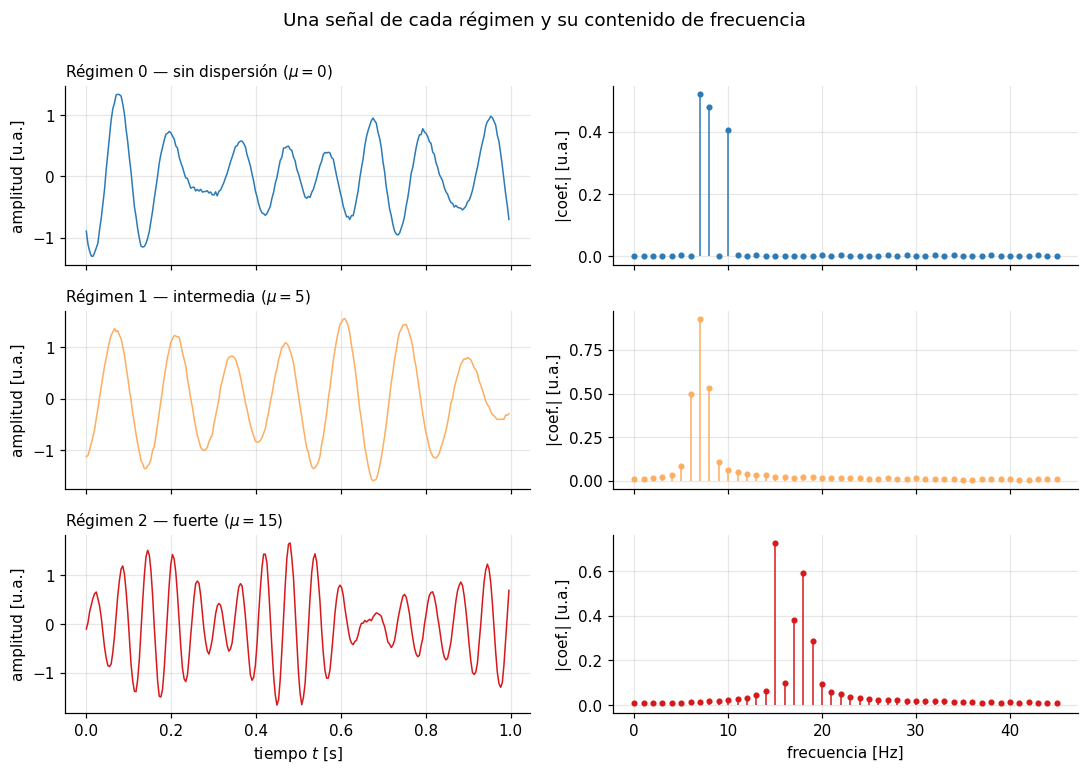

In [43]:
fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex="col")
nombres = ["Régimen 0 — sin dispersión ($\\mu=0$)", "Régimen 1 — intermedia ($\\mu=5$)", "Régimen 2 — fuerte ($\\mu=15$)"]
freqs = np.fft.rfftfreq(N, d=t[1]-t[0])
for r in range(3):
    x = X[np.where(y == r)[0][0]]
    axes[r, 0].plot(t, x, color=C_REG[r], lw=1)
    axes[r, 0].set_ylabel("amplitud [u.a.]")
    axes[r, 0].set_title(nombres[r], loc="left", fontsize=10)
    esp = np.abs(np.fft.rfft(x)) * 2 / N
    m, s, b = axes[r, 1].stem(freqs[:46], esp[:46], basefmt=" ")
    plt.setp(m, color=C_REG[r], markersize=3); plt.setp(s, color=C_REG[r], lw=1)
    axes[r, 1].set_ylabel("|coef.| [u.a.]")
axes[2, 0].set_xlabel("tiempo $t$ [s]")
axes[2, 1].set_xlabel("frecuencia [Hz]")
fig.suptitle("Una señal de cada régimen y su contenido de frecuencia", y=1.0)
fig.tight_layout()
plt.show()

A mayor $\mu$, la relación de dispersión $\omega(k)=\sqrt{k^2+\mu^2}$ empuja los tres modos de cada señal hacia frecuencias más altas — exactamente lo que muestran los espectros. Nótese además que para $\mu>0$ las frecuencias $\omega(k)/2\pi$ **dejan de ser enteras**: los picos no caen exactamente sobre la rejilla de Fourier y se produce *fuga espectral* (picos con "faldas"). Esto será relevante en la compresión (§5).

## 2 · La capa Fourier (rúbrica: 15 pts)

$W_1 \in \mathbb{R}^{2K\times 256}$: las primeras $K$ filas son $\cos(2\pi k t)$ y las siguientes $K$ son $\sin(2\pi k t)$, con $k = 1,\dots,30$. En su inicialización, $W_1 x$ entrega exactamente $\operatorname{Re}(X_k)$ y $-\operatorname{Im}(X_k)$ de la DFT, es decir, **la capa calcula los primeros $K$ coeficientes de la transformada de Fourier** — se verifica abajo contra `np.fft`.

**¿Entradas y salidas de `np.fft.fft`? ¿Una señal o varias?** Recibe un arreglo real (o complejo) y devuelve un arreglo **complejo** del mismo largo con los coeficientes $X_k$ (parte real = componente coseno, parte imaginaria = $-$componente seno). Con el argumento `axis` se aplica a **todas las señales a la vez**: `np.fft.fft(X, axis=1)` transforma las 36 filas de una sola llamada — y la capa hace lo mismo, porque una multiplicación de matrices `X @ W1.T` procesa el lote completo. La verificación de abajo se hace, por eso, sobre **todo el dataset**.

In [44]:
def matriz_fourier(K, t, escala=1.0):
    '''Filas: cos(2*pi*k*t) para k=1..K, luego sin(2*pi*k*t). Forma (2K, len(t)).'''
    k = np.arange(1, K + 1)[:, None]
    C = np.cos(2 * np.pi * k * t[None, :])
    S = np.sin(2 * np.pi * k * t[None, :])
    return escala * np.vstack([C, S])

F = matriz_fourier(K, t)                  # sin escala, para comparar con la FFT
coefs_capa = X @ F.T                      # (36, 2K): la capa aplicada a TODO el dataset
fft_np = np.fft.fft(X, axis=1)            # FFT de las 36 señales a la vez

ok_cos = np.allclose(coefs_capa[:, :K],  fft_np[:, 1:K+1].real)
ok_sin = np.allclose(coefs_capa[:, K:], -fft_np[:, 1:K+1].imag)
print(f"filas coseno == Re(FFT[k=1..30])  -> {ok_cos}")
print(f"filas seno   == -Im(FFT[k=1..30]) -> {ok_sin}")
print(f"máxima discrepancia: {np.abs(coefs_capa[:, :K] - fft_np[:, 1:K+1].real).max():.2e}")

filas coseno == Re(FFT[k=1..30])  -> True
filas seno   == -Im(FFT[k=1..30]) -> True
máxima discrepancia: 7.60e-13


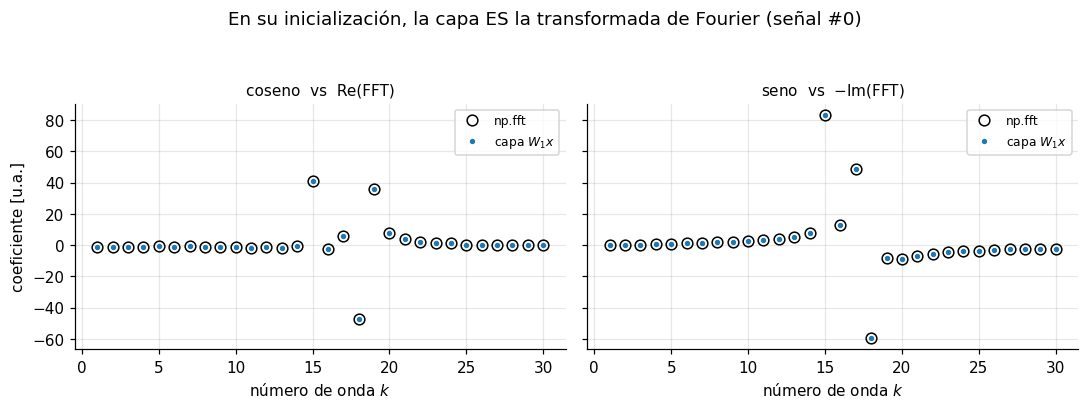

In [45]:
i0 = 0
ks = np.arange(1, K + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for ax, parte, capa, ref in [
    (axes[0], "coseno  vs  Re(FFT)",  coefs_capa[i0, :K],  fft_np[i0, 1:K+1].real),
    (axes[1], "seno  vs  $-$Im(FFT)", coefs_capa[i0, K:], -fft_np[i0, 1:K+1].imag),
]:
    ax.plot(ks, ref, "o", ms=7, mfc="none", color="k", label="np.fft")
    ax.plot(ks, capa, ".", ms=5, color=C_FOURIER, label="capa $W_1x$")
    ax.set_xlabel("número de onda $k$"); ax.set_title(parte, fontsize=10)
    ax.legend(fontsize=8, loc="best", frameon=True, facecolor="white", framealpha=0.8)
axes[0].set_ylabel("coeficiente [u.a.]")
fig.suptitle("En su inicialización, la capa ES la transformada de Fourier (señal #0)", y=1.05)
fig.tight_layout(); plt.show()

## 3 · La red en JAX y su entrenamiento (rúbrica: 25 pts)

$$\hat x = W_2\tanh(W_1x), \qquad \mathcal{L}=\frac1N\sum_{i=1}^{N}\lVert\hat x_i - x_i\rVert^2,$$

con $N$ = número de señales del lote. Descenso de gradiente con $\eta = 0.02$ durante **2000 iteraciones** (parámetros del enunciado).

**Decisiones de diseño (y por qué):**

- **Escala de la inicialización Fourier.** La matriz de Fourier cruda produce coeficientes $\sim\!\tfrac{N}{2}a_j\approx 100$, que saturan la $\tanh$ y matan los gradientes. Se usa $W_1 = \tfrac{2}{256}F$, que entrega directamente las *amplitudes* $a_j\in[0.3,1]$ — dentro de la zona útil de la $\tanh$ y sin alterar la propiedad de la §2 (es la FFT, reescalada).
- **Inicialización aleatoria comparable.** Glorot ($\sigma=\sqrt{2/(256+60)}$), que produce activaciones de magnitud similar. Así la comparación aísla la *estructura* (base de Fourier vs direcciones aleatorias) y no la escala. En §4 se muestra qué pasa si la escala aleatoria se elige mal.
- **$W_2$ idéntica en ambos casos** (misma semilla): lo único que cambia es el punto de partida de $W_1$, como pide el enunciado.
- **Partición entrenamiento/validación.** ¿El error de reconstrucción debe medirse en datos de entrenamiento o de validación? *En ambos*: el de entrenamiento mide si la optimización funcionó; el de validación mide si la red **generaliza**. Se reservan 2 señales por régimen (30 train / 6 val, estratificado) y se reportan los dos.

In [46]:
# ---------------------------------------------------------------------------
# Partición estratificada: 10 señales de entrenamiento y 2 de validación por
# régimen. Semilla única de todo el trabajo: 3714 (4 dígitos de la cédula).
# ---------------------------------------------------------------------------
rng = np.random.default_rng(3714)                  # misma semilla en TODO el notebook
idx_tr, idx_va = [], []
for r in range(3):
    perm = rng.permutation(np.where(y == r)[0])    # baraja las 12 señales del régimen r
    idx_tr += list(perm[:10]); idx_va += list(perm[10:])   # 10 entrenan, 2 validan
idx_tr, idx_va = np.array(idx_tr), np.array(idx_va)
Xtr, ytr = jnp.array(X[idx_tr]), y[idx_tr]
Xva, yva = jnp.array(X[idx_va]), y[idx_va]
print(f"entrenamiento: {Xtr.shape[0]} señales | validación: {Xva.shape[0]} señales")

# ---------------------------------------------------------------------------
# Red, pérdida y entrenamiento
# ---------------------------------------------------------------------------
KEY = jax.random.PRNGKey(3714)   # key de JAX = 4 dígitos de la cédula (directriz del curso)

def init_params(modo, key, escala_rand=None):
    '''Pesos iniciales [W1, W2]. Solo W1 cambia según `modo`; W2 es idéntica en ambos casos.'''
    k1, k2 = jax.random.split(key)          # subkeys deterministas derivadas de la key 3714
    if modo == "fourier":
        # W1 = matriz de Fourier (filas cos/sin de la §2) reescalada por 2/N para que
        # sus salidas sean amplitudes ~O(1) y no saturen la tanh (sigue siendo la FFT)
        W1 = jnp.array(matriz_fourier(K, t, escala=2.0 / N))
    else:
        # W1 aleatoria Glorot (o con la escala pedida, para el experimento de la §4)
        s = escala_rand if escala_rand is not None else jnp.sqrt(2.0 / (N + 2 * K))
        W1 = s * jax.random.normal(k1, (2 * K, N))
    W2 = jax.random.normal(k2, (N, 2 * K)) * jnp.sqrt(2.0 / (N + 2 * K))  # mismo k2 => W2 igual en ambos casos
    return [W1, W2]

# Paso forward: la capa 1 proyecta la señal (x @ W1.T), la tanh introduce la
# no linealidad y la capa 2 reconstruye:  x_hat = W2 tanh(W1 x)
def forward(p, x):  return jnp.tanh(x @ p[0].T) @ p[1].T
# Pérdida del enunciado: L = (1/N) sum_i ||x_hat_i - x_i||^2 (promedio sobre el lote)
def perdida(p, x):  return jnp.mean(jnp.sum((forward(p, x) - x) ** 2, axis=1))
# Error relativo por señal: ||x_hat - x|| / ||x|| (adimensional; el criterio 0.1 usa este)
def err_rel(p, x):  return jnp.linalg.norm(forward(p, x) - x, axis=1) / jnp.linalg.norm(x, axis=1)

ETA, ITERS = 0.02, 2000        # tasa de aprendizaje y n° de iteraciones (enunciado)

@jax.jit
def paso(p):
    '''Una iteración de descenso de gradiente sobre el conjunto de entrenamiento.'''
    # jax.grad construye, por diferenciación automática, la función gradiente de la
    # pérdida respecto de p = [W1, W2]; devuelve una lista con la misma estructura que p.
    g = jax.grad(perdida)(p, Xtr)
    # actualización de descenso de gradiente: W <- W - eta * dL/dW
    return [w - ETA * gw for w, gw in zip(p, g)]

def entrenar(modo, escala_rand=None, seguimiento=True):
    '''Entrena 2000 iteraciones; devuelve pesos finales e historiales
    (pérdida y errores relativos train/val/régimen 1 por iteración).'''
    p = init_params(modo, KEY, escala_rand)   # misma key 3714 en TODOS los entrenamientos
    h = {"L": [], "rel_tr": [], "rel_va": [], "rel_r1": []}
    for _ in range(ITERS):
        p = paso(p)                                    # un paso de gradiente
        h["L"].append(float(perdida(p, Xtr)))          # historial de la pérdida
        if seguimiento:                                # historiales de error relativo
            r = err_rel(p, Xtr)
            h["rel_tr"].append(float(r.mean()))               # media en entrenamiento
            h["rel_r1"].append(float(r[ytr == 1].mean()))     # solo régimen 1 (foco del enunciado)
            h["rel_va"].append(float(err_rel(p, Xva).mean())) # media en validación
    return p, {k: np.array(v) for k, v in h.items()}

p_fou, h_fou = entrenar("fourier")
p_ale, h_ale = entrenar("aleatoria")
print("entrenamiento terminado (2000 iteraciones por inicialización)")

entrenamiento: 30 señales | validación: 6 señales
entrenamiento terminado (2000 iteraciones por inicialización)


In [47]:
# --- errores de reconstrucción relativos ||x_hat - x|| / ||x|| ---------------
def tabla_errores(p, nombre):
    rtr, rva = err_rel(p, Xtr), err_rel(p, Xva)
    print(f"\n{nombre}")
    print(f"  global      -> train: {float(rtr.mean()):.3f}   val: {float(rva.mean()):.3f}")
    for r in range(3):
        print(f"  régimen {r}   -> train: {float(rtr[ytr == r].mean()):.3f}   val: {float(rva[yva == r].mean()):.3f}")

tabla_errores(p_fou, "Inicialización FOURIER (error relativo final)")
tabla_errores(p_ale, "Inicialización ALEATORIA (error relativo final)")


Inicialización FOURIER (error relativo final)
  global      -> train: 0.007   val: 0.606
  régimen 0   -> train: 0.005   val: 0.748
  régimen 1   -> train: 0.009   val: 0.479
  régimen 2   -> train: 0.007   val: 0.591

Inicialización ALEATORIA (error relativo final)
  global      -> train: 0.007   val: 0.640
  régimen 0   -> train: 0.005   val: 0.805
  régimen 1   -> train: 0.008   val: 0.537
  régimen 2   -> train: 0.006   val: 0.578


**Lectura.** Ambas redes reconstruyen casi perfecto el conjunto de entrenamiento (error relativo $\approx 0.007$) pero fallan en validación ($\approx 0.5$–$0.8$): con 30 señales de entrenamiento y cada señal compuesta por modos, amplitudes y fases sorteados al azar, la red **memoriza** en vez de generalizar — el clásico sobreajuste. Por eso la pregunta de la rúbrica importa: reportar solo el error de entrenamiento daría una impresión engañosamente optimista. La diferencia entre las dos inicializaciones, en cambio, es mínima en ambos conjuntos (ver §4).

La figura muestra la señal original y su reconstrucción final para **una señal de cada régimen**, en datos de entrenamiento (izquierda, reconstrucción excelente) y de validación (derecha, donde se aprecia el sobreajuste).

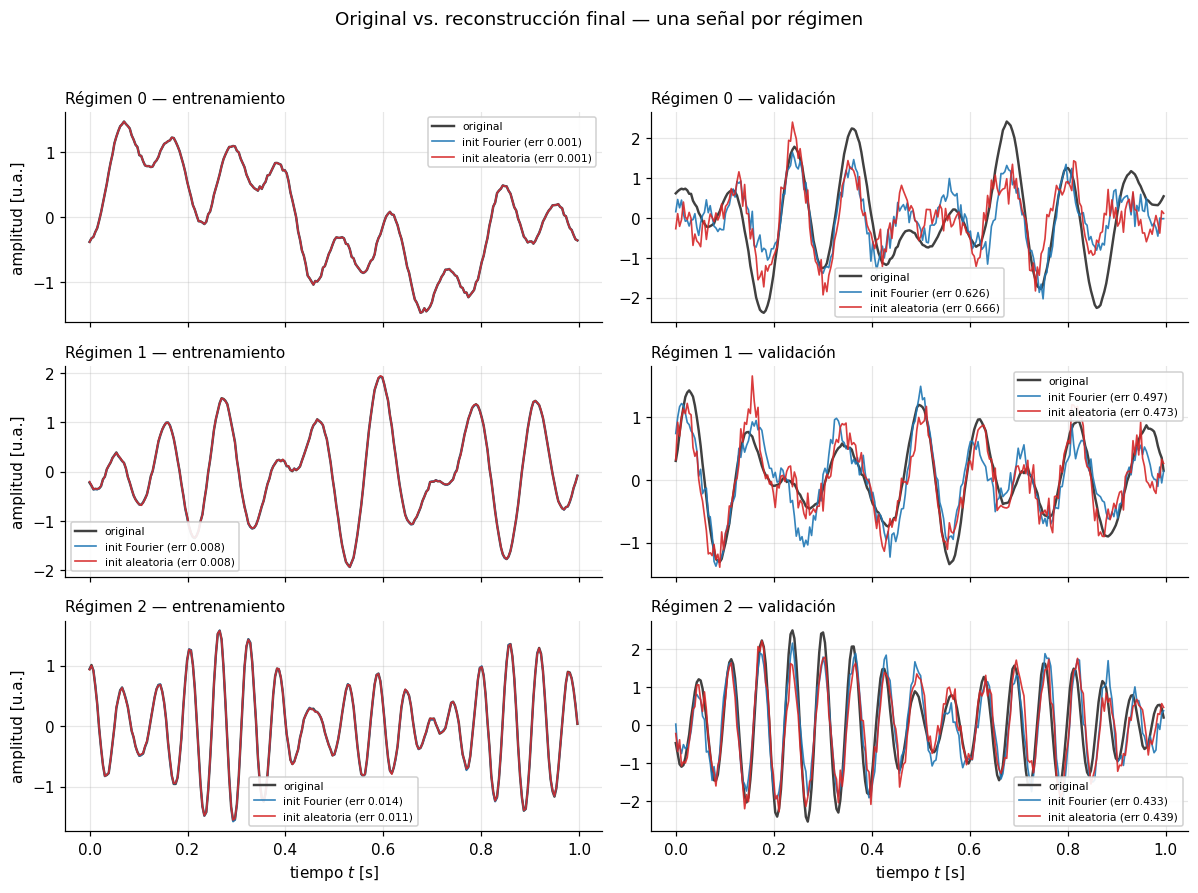

In [48]:
fig, axes = plt.subplots(3, 2, figsize=(11, 8.5), sharex=True)
for r in range(3):
    for c, (Xs, ys, titulo) in enumerate([(Xtr, ytr, "entrenamiento"), (Xva, yva, "validación")]):
        i = np.where(ys == r)[0][0]
        x = np.asarray(Xs[i])
        ax = axes[r, c]
        ax.plot(t, x, color="0.25", lw=1.6, label="original")
        for p, nom, col in [(p_fou, "init Fourier", C_FOURIER), (p_ale, "init aleatoria", C_RANDOM)]:
            xh = np.asarray(forward(p, Xs[i:i+1]))[0]
            e = np.linalg.norm(xh - x) / np.linalg.norm(x)
            ax.plot(t, xh, lw=1.1, color=col, alpha=0.9, label=f"{nom} (err {e:.3f})")
        ax.set_title(f"Régimen {r} — {titulo}", loc="left", fontsize=10)
        # Ajuste fino de leyenda: ubicación 'best' con fondo opaco para legibilidad
        ax.legend(fontsize=7, loc="best", frameon=True, facecolor="white", framealpha=0.9, edgecolor="0.8")
        if c == 0: ax.set_ylabel("amplitud [u.a.]")
for ax in axes[2]: ax.set_xlabel("tiempo $t$ [s]")
fig.suptitle("Original vs. reconstrucción final — una señal por régimen", y=0.98)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 4 · Comparación de inicializaciones (rúbrica: 25 pts)

**¿La pérdida es el error relativo?** No: la pérdida es $\mathcal{L}=\frac1N\sum\lVert\hat x-x\rVert^2$ (cuadrática, con unidades de energía) y el error relativo es $\lVert\hat x-x\rVert/\lVert x\rVert$ (adimensional). Se relacionan de forma monótona, pero el criterio "error relativo $\le 0.1$" se mide con la segunda cantidad. Abajo se grafican ambas.

init Fourier  : error relativo <= 0.1 en 146 iteraciones
init aleatoria: error relativo <= 0.1 en 120 iteraciones


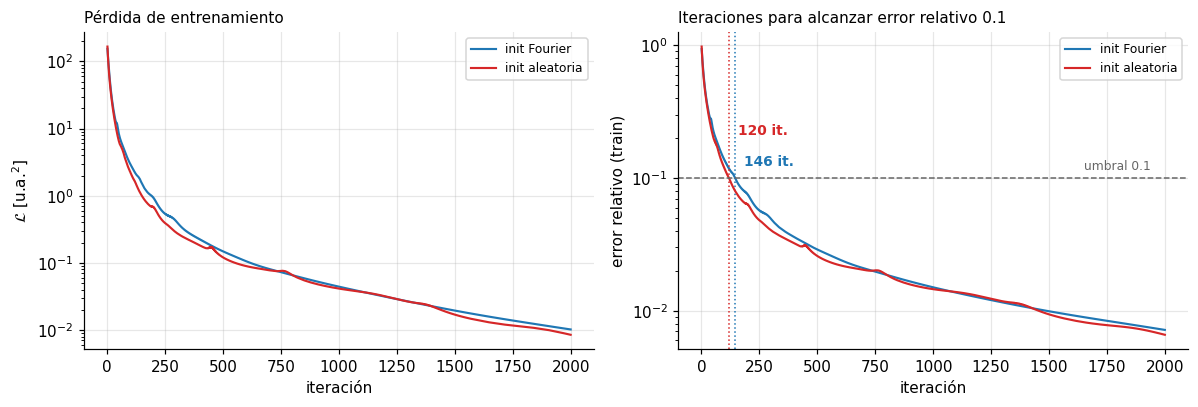

In [49]:
it = np.arange(1, ITERS + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# pérdida (rúbrica: L vs iteraciones, superpuestas)
axes[0].semilogy(it, h_fou["L"], color=C_FOURIER, lw=1.4, label="init Fourier")
axes[0].semilogy(it, h_ale["L"], color=C_RANDOM,  lw=1.4, label="init aleatoria")
axes[0].set_xlabel("iteración"); axes[0].set_ylabel("$\\mathcal{L}$ [u.a.$^2$]")
axes[0].set_title("Pérdida de entrenamiento", loc="left", fontsize=10)
# Ajuste de leyenda optimizado
axes[0].legend(fontsize=8, loc="best", frameon=True, facecolor="white", framealpha=0.8)

# error relativo + criterio 0.1
umbral = 0.1
# Se define un desplazamiento vertical distinto para cada etiqueta y evitar el solapamiento
for i, (h, col, nom) in enumerate([(h_fou, C_FOURIER, "Fourier"), (h_ale, C_RANDOM, "aleatoria")]):
    axes[1].semilogy(it, h["rel_tr"], color=col, lw=1.4, label=f"init {nom}")
    n_it = int(np.argmax(h["rel_tr"] <= umbral)) + 1
    axes[1].axvline(n_it, color=col, ls=":", lw=1)
    # Offset vertical incrementado para asegurar separación clara (8 para Fourier, 28 para aleatoria)
    y_off = 8 + i * 20
    axes[1].annotate(f"{n_it} it.", (n_it, umbral), textcoords="offset points",
                     xytext=(6, y_off), color=col, fontsize=9, fontweight="bold")
    print(f"init {nom:9s}: error relativo <= 0.1 en {n_it} iteraciones")
axes[1].axhline(umbral, color="0.4", ls="--", lw=1)
axes[1].text(1650, umbral * 1.15, "umbral 0.1", color="0.4", fontsize=8)
axes[1].set_xlabel("iteración"); axes[1].set_ylabel("error relativo (train)")
axes[1].set_title("Iteraciones para alcanzar error relativo 0.1", loc="left", fontsize=10)
# Ajuste de leyenda optimizado
axes[1].legend(fontsize=8, loc="best", frameon=True, facecolor="white", framealpha=0.8)
fig.tight_layout(); plt.show()

### El régimen foco del enunciado: régimen 1

El enunciado pide contrastar la **velocidad de convergencia en el régimen 1** (dispersión intermedia). Se grafica el error relativo *solo de las señales del régimen 1* durante las primeras iteraciones, junto con un experimento adicional: ¿qué pasa si la inicialización aleatoria tiene una escala mal elegida?

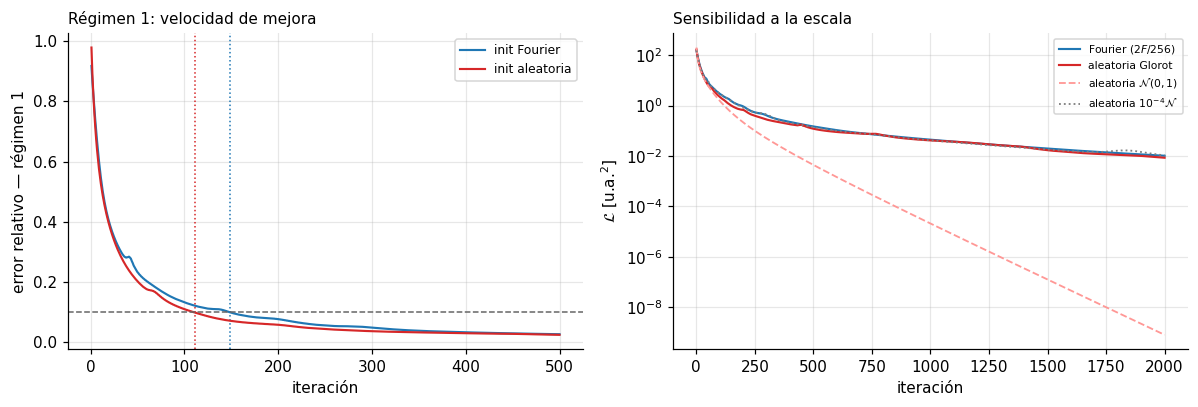

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
zoom = 500
for h, col, nom in [(h_fou, C_FOURIER, "Fourier"), (h_ale, C_RANDOM, "aleatoria")]:
    axes[0].plot(it[:zoom], h["rel_r1"][:zoom], color=col, lw=1.4, label=f"init {nom}")
    n1 = int(np.argmax(h["rel_r1"] <= 0.1)) + 1
    axes[0].axvline(n1, color=col, ls=":", lw=1)
axes[0].axhline(0.1, color="0.4", ls="--", lw=1)
axes[0].set_xlabel("iteración"); axes[0].set_ylabel("error relativo — régimen 1")
axes[0].set_title("Régimen 1: velocidad de mejora", loc="left", fontsize=10)
axes[0].legend(fontsize=8, loc="best", frameon=True, facecolor="white", framealpha=0.8)
_, h_n01  = entrenar("aleatoria", escala_rand=1.0,  seguimiento=False)
_, h_tiny = entrenar("aleatoria", escala_rand=1e-4, seguimiento=False)
axes[1].semilogy(it, h_fou["L"], color=C_FOURIER, lw=1.4, label="Fourier ($2F/256$)")
axes[1].semilogy(it, h_ale["L"], color=C_RANDOM, lw=1.4, label="aleatoria Glorot")
axes[1].semilogy(it, h_n01["L"], color="#ff9896", lw=1.2, ls="--", label="aleatoria $\\mathcal{N}(0,1)$")
axes[1].semilogy(it, h_tiny["L"], color="#7f7f7f", lw=1.2, ls=":", label="aleatoria $10^{-4}\\mathcal{N}$")
axes[1].set_xlabel("iteración"); axes[1].set_ylabel("$\\mathcal{L}$ [u.a.$^2$]")
axes[1].set_title("Sensibilidad a la escala", loc="left", fontsize=10)
axes[1].legend(fontsize=7, loc="best", frameon=True, facecolor="white", framealpha=0.8)
fig.tight_layout(); plt.show()

**Análisis (respuesta con evidencia propia).**

Con una inicialización aleatoria *bien escalada* (Glorot), arrancar en la base de Fourier **no da ventaja de velocidad** en estos datos: el error relativo global cruza 0.1 en 146 iteraciones (Fourier) vs. 120 (aleatoria), y en el régimen 1 la aleatoria también cruza antes (111 vs. 149). ¿Por qué no gana Fourier? Porque con $2K = 60$ unidades ocultas la capa aleatoria ya define 60 proyecciones linealmente independientes que capturan de sobra los ~3 modos activos de cada señal; el descenso de gradiente ajusta $W_2$ (un problema casi lineal) igual de rápido en ambos casos.

El panel derecho muestra dónde **sí** importa el punto de partida: es un asunto de **escala**, no de estructura. Con $W_1\sim\mathcal{N}(0,1)$ la $\tanh$ arranca saturada y con $W_1\approx 0$ la señal casi no atraviesa la primera capa; en ambos extremos la dinámica inicial cambia de forma visible. La inicialización de Fourier es valiosa sobre todo porque **garantiza automáticamente una escala y una diversidad correctas** — y porque hace la capa *interpretable*: sus salidas son coeficientes espectrales, lo que habilita la compresión de la §5.

## 5 · Compresión (rúbrica: 10 pts)

En su inicialización, la capa Fourier entrega los coeficientes $(c_k^{\cos}, c_k^{\sin})$ de cada señal. La energía del modo $k$ es $E_k = (c_k^{\cos})^2 + (c_k^{\sin})^2 \propto a_k^2$. Ordenamos los modos por energía y reconstruimos conservando solo los $m$ más energéticos:

$$\hat x_m(t) = \sum_{k \in \text{top-}m} \left[c_k^{\cos}\cos(2\pi kt) + c_k^{\sin}\sin(2\pi kt)\right].$$

Se reporta (i) el error de reconstrucción vs. $m$ y (ii) cuántos modos concentran el **90 % de la energía** (umbral del enunciado). Aquí "un coeficiente" = un par seno–coseno (un modo $k$)= 2 números reales.

In [51]:
# Coeficientes de amplitud de TODO el dataset con la capa Fourier inicial (2F/N):
Cf = (2.0 / N) * (X @ F.T)                 # (36, 2K): [cos_1..cos_K | sin_1..sin_K] por señal
# Energía del modo k: E_k = c_cos^2 + c_sin^2 (proporcional a a_k^2, Parseval)
E = Cf[:, :K] ** 2 + Cf[:, K:] ** 2        # (36, K): energía por modo y por señal

# --- cuántos modos concentran el 90 % de la energía, por señal ---------------
orden = np.argsort(E, axis=1)[:, ::-1]                         # modos de mayor a menor energía
E_ord = np.take_along_axis(E, orden, axis=1)                   # energías ordenadas
cum = np.cumsum(E_ord, axis=1) / E.sum(axis=1, keepdims=True)  # fracción de energía acumulada
m90 = (cum >= 0.90).argmax(axis=1) + 1                         # primer m que alcanza el 90 %

# --- error de reconstrucción vs número de modos conservados ------------------
ks_all = np.arange(1, K + 1)
COS, SIN = np.cos(2 * np.pi * ks_all[:, None] * t), np.sin(2 * np.pi * ks_all[:, None] * t)
err_m = np.zeros((K, len(X)))
for m in range(1, K + 1):
    for i in range(len(X)):
        top = orden[i, :m]                                      # los m modos más energéticos de la señal i
        xr = Cf[i, top] @ COS[top] + Cf[i, K + top] @ SIN[top]  # reconstrucción truncada a esos m modos
        err_m[m - 1, i] = np.linalg.norm(xr - X[i]) / np.linalg.norm(X[i])  # error relativo

print(f"modos (pares sen-cos) para el 90% de la energía: mediana {int(np.median(m90))}, "
      f"media {m90.mean():.2f}, máximo {m90.max()}")
for r in range(3):
    print(f"  régimen {r}: m90 = {[int(v) for v in sorted(m90[y == r])]}")
print(f"error relativo medio conservando m=3 modos: {err_m[2].mean():.3f}")

modos (pares sen-cos) para el 90% de la energía: mediana 3, media 3.67, máximo 7
  régimen 0: m90 = [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  régimen 1: m90 = [2, 3, 3, 3, 3, 4, 4, 4, 4, 6, 6, 7]
  régimen 2: m90 = [2, 3, 3, 3, 3, 4, 4, 4, 4, 5, 6, 6]
error relativo medio conservando m=3 modos: 0.239


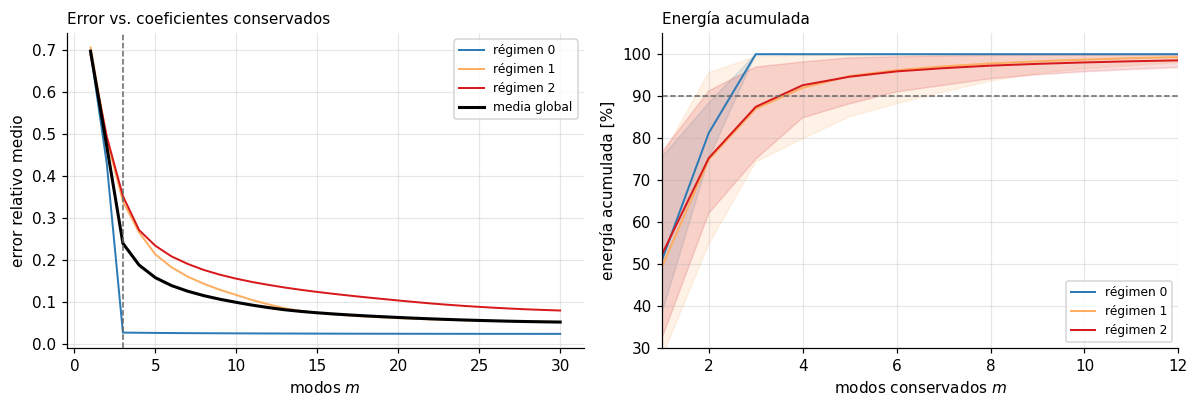

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for r in range(3):
    axes[0].plot(ks_all, err_m[:, y == r].mean(axis=1), color=C_REG[r], lw=1.3, label=f"régimen {r}")
axes[0].plot(ks_all, err_m.mean(axis=1), color="k", lw=2, label="media global")
axes[0].axvline(int(np.median(m90)), color="0.4", ls="--", lw=1)
axes[0].set_xlabel("modos $m$"); axes[0].set_ylabel("error relativo medio")
axes[0].set_title("Error vs. coeficientes conservados", loc="left", fontsize=10)
axes[0].legend(fontsize=8, loc="best", frameon=True, facecolor="white", framealpha=0.8)
for r in range(3):
    cr = cum[y == r]
    axes[1].plot(ks_all, cr.mean(axis=0) * 100, color=C_REG[r], lw=1.3, label=f"régimen {r}")
    axes[1].fill_between(ks_all, cr.min(axis=0) * 100, cr.max(axis=0) * 100, color=C_REG[r], alpha=0.15)
axes[1].axhline(90, color="0.4", ls="--", lw=1)
axes[1].set_xlabel("modos conservados $m$"); axes[1].set_ylabel("energía acumulada [%]")
axes[1].set_xlim(1, 12); axes[1].set_ylim(30, 105)
axes[1].set_title("Energía acumulada", loc="left", fontsize=10)
axes[1].legend(fontsize=8, loc="best", frameon=True, facecolor="white", framealpha=0.8)
fig.tight_layout(); plt.show()

**Lectura.** Cada señal se generó con 3 modos, y eso es exactamente lo que la compresión revela: la **mediana es $m_{90}=3$ pares seno–coseno** (6 números reales de 256 muestras: compresión ~43×). En el régimen 0 *todas* las señales necesitan exactamente 3 modos, porque con $\mu=0$ las frecuencias son enteras y caen limpias sobre la rejilla de Fourier. En los regímenes 1 y 2 algunas señales requieren 4–7 modos: la dispersión hace las frecuencias $\omega(k)/2\pi$ no enteras, la energía se "fuga" a bins vecinos y hacen falta más coeficientes para juntar el 90 %. La misma fuga explica que el error relativo con $m=3$ quede en ~0.24 en promedio y no en ~0: la base de Fourier *entera* ya no es exactamente la base natural de un medio dispersivo — otra razón por la que dejar que la red *siga entrenando* $W_1$ tiene sentido.

## 6 · Conclusiones

**1. La capa Fourier funciona como se anuncia.** En su inicialización reproduce exactamente `np.fft` (coincide con Re/−Im de los coeficientes $k=1..30$ para las 36 señales, discrepancia ~10⁻¹³). Energía media del dataset: **0.715**.

**2. Reconstrucción.** Con los parámetros del enunciado (2000 iteraciones, $\eta=0.02$) ambas inicializaciones logran un error relativo de entrenamiento ≈ **0.007**; en validación el error queda en ≈ 0.61 (Fourier) y ≈ 0.64 (aleatoria) — sobreajuste esperable con 30 señales de parámetros aleatorios. Reportar el error de validación es imprescindible para no sobrevender el resultado.

**3. ¿Ayuda arrancar en Fourier?** *En estos datos y con esta arquitectura, no en velocidad:* 146 vs. 120 iteraciones para alcanzar error relativo 0.1 (y en el régimen 1, 149 vs. 111 — la aleatoria cruza antes). La ventaja real de Fourier no es la velocidad sino la **robustez de escala** (una aleatoria mal escalada sí arranca mucho peor) y la **interpretabilidad**: sus salidas son coeficientes espectrales.

**4. Compresión.** El 90 % de la energía vive en una mediana de **3 pares seno–coseno** por señal (media 3.67, máximo 7) — consistente con la física: 3 modos por señal, con fuga espectral adicional en los regímenes dispersivos.